In [1]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy
import math

sr = 22050
def makesine(freq, dur):
    t = numpy.linspace(0, dur, math.ceil(sr*dur))
    x = numpy.sin(2 * numpy.pi * freq * t)
    return x
def addsyn(freq, dur, amplist):
    i = 1
    t = numpy.linspace(0, dur, math.ceil(sr*dur))
    ### initialize a new output
    out = numpy.zeros(t.size)
    for amp in amplist:
        ### make a sine waveform with this max amplitude
        ### frequency is the integer multiple 
        x = numpy.multiply(makesine(freq*i, dur), amp)
        ### sum it to the output
        out = out + x
        i+=1
    ### making sure the maximum amplitude does not exeed 1
    if numpy.max(out)>abs(numpy.min(out)):
        out = out / numpy.max(out)
    else:
        out = out / -numpy.min(out)
    return out

# Blending pure tones: Additive Synthesis from scratch with Python code

There are a few basic waveforms that are commonly seen in analog synthesizers as building blocks for more complex sounds. But indeed, they can all be built from the purest sound—sine waves! You just need the ***correct recipe*** for the combination.

Although we hear the vibration of a single frequency as a single pitch, the harmonious sound from musical instruments all happen to have a ***collection of frequencies*** for every single pitch. With a different recipe of combination of these frequencies, the tone colour (***timbre***) differs.


> Timbre /ˈtambə/: The character or quality of a musical or vocal sound ([Oxford English Dictionary](https://www.oed.com/view/Entry/202089))

The set of harmonics is an important base of the timbre. Technically, we need to look for an appropriate proportion of the fundamental frequency and its ***integer multiples***.

### A Violin Sound

For example, a violin sound of A440 has a fundamental frequency of **440 Hz**. On top of it, the sound also has a mix of **880 Hz** (440×2), **1320 Hz** (440×3), **1760 Hz** (440×4), and so on. Let’s use this table of secret recipe that we can find using some sound analysis tools. *Ignore the vibrato for the moment…*


![Picture title](image-20220711-182926.png)

In [2]:
ipd.Audio("violin-a440.wav")

With a very simple synthesis, it sounds like this:

In [3]:
violin = addsyn(440, 1, [1, 0.263, 0.14, 0.099, 0.209, 0.02, 0.029, 0.077, 0.017, 0.01])
ipd.Audio(violin, rate=sr)

Try comparing it with the pure sine tone. It sounds so different, isn’t it?

In [4]:
sinewave = addsyn(440, 1, [1])
ipd.Audio(sinewave, rate=sr)

To mix pure sine tones into a new timbre is called ***additive synthesis***. Let’s do this step by step with Python code!

> Don't worry. It's not so addictive...

### Additive Synthesis with Python

We start with importing the necessary libraries—`IPython` for showing the sound player, `matplotlib` for plotting charts, `numpy` for arrays, and `math` for some mathematical functions. We also define the sampling rate `sr`.

In [1]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy
import math

sr = 22050

We have seen making a pure sine waveform before. We can put the code into a function `makesine()` to easily reuse it:

In [2]:
def makesine(freq, dur):
    t = numpy.linspace(0, dur, math.ceil(sr*dur))
    x = numpy.sin(2 * numpy.pi * freq * t)
    return x

Then, we can run `makesine()` several times to make a new waveform, with certain frequency `freq` and duration `dur`. We can put all of them together using `numpy.concatenate()`.

In [3]:
output = numpy.array(())
y = makesine(261.63, .5) # C for 0.5 seconds
output = numpy.concatenate((output, y))
y = makesine(293.66, .5) # D for 0.5 seconds
output = numpy.concatenate((output, y))
y = makesine(329.63, .5) # E for 0.5 seconds
output = numpy.concatenate((output, y))
ipd.Audio(output, rate=sr)

The basic sine wave sounds pretty good! Now let’s make more sine waves with frequencies at integer multiples using `freq*i`, where `i` is a counter from `1` and adds 1 every time. The sine waves need to softened into the predefined amplitudes in `amplist`. They are then stacked up in `out`.

In [4]:
def addsyn(freq, dur, amplist):
    i = 1
    t = numpy.linspace(0, dur, math.ceil(sr*dur))
    ### initialize a new output
    out = numpy.zeros(t.size)
    for amp in amplist:
        ### make a sine waveform with this max amplitude
        ### frequency is the integer multiple 
        x = numpy.multiply(makesine(freq*i, dur), amp)
        ### sum it to the output
        out = out + x
        i+=1
    ### making sure the maximum amplitude does not exeed 1
    if numpy.max(out)>abs(numpy.min(out)):
        out = out / numpy.max(out)
    else:
        out = out / -numpy.min(out)
    return out

### Basic Waveforms with Additive Synthesis

Now, here are the common basic waveforms re-created with a simple additive synthesizer which only includes the *first 10 harmonics*: *(I’m too lazy to obtain more harmonic amplitudes…)*

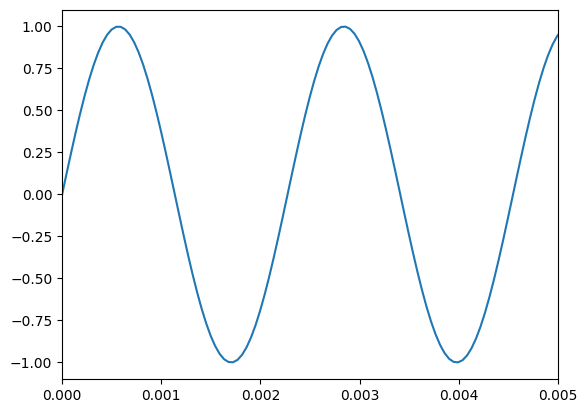

In [6]:
t = numpy.linspace(0, 1, sr)
sinewave = addsyn(440, 1, [1]) # Only one harmonic (the fundamental)
plt.plot(t, sinewave)
plt.xlim(0, 0.005) # Show only 0.005 seconds to see waveform shape
ipd.Audio(sinewave, rate=sr)

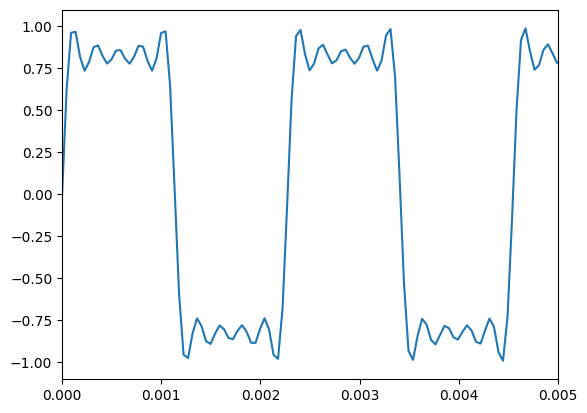

In [7]:
squarewave = addsyn(440, 1, [1, 0, 0.339, 0, 0.204, 0, 0.155, 0, 0.111, 0])
plt.plot(t, squarewave)
plt.xlim(0, 0.005)
ipd.Audio(squarewave, rate=sr)

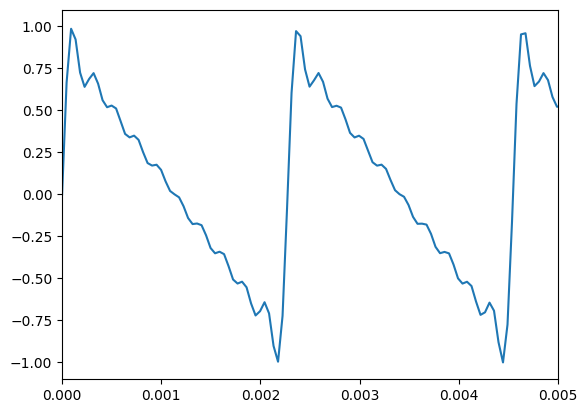

In [8]:
sawtoothwave = addsyn(440, 1, [1, 0.501, 0.339, 0.24, 0.202, 0.168, 0.155, 0.123, 0.111, 0.102])
plt.plot(t, sawtoothwave)
plt.xlim(0, 0.005)
ipd.Audio(sawtoothwave, rate=sr)

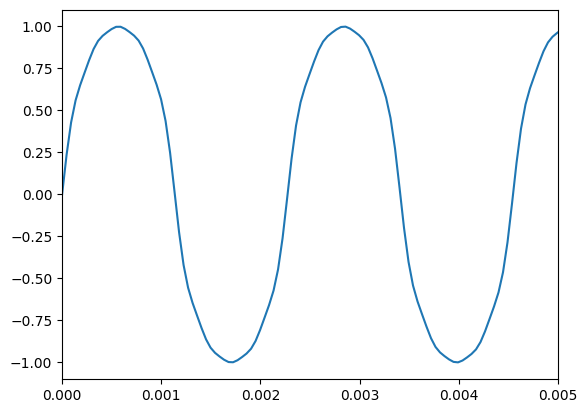

In [12]:
trianglewave = addsyn(440, 1, [1, 0, 0.112, 0, 0.04, 0, 0.022, 0, 0.012, 0])
plt.plot(t, trianglewave)
plt.xlim(0, 0.005)
ipd.Audio(trianglewave, rate=sr)

And here's the violin again!

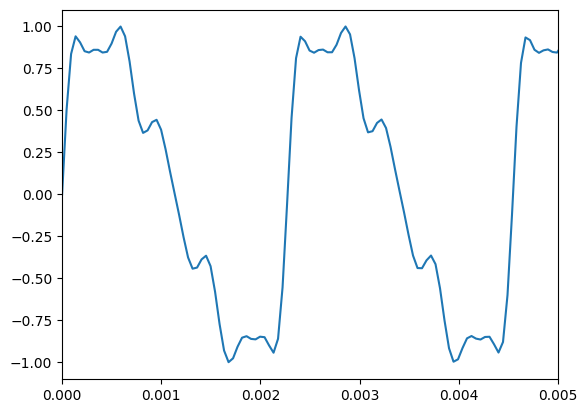

In [13]:
violin = addsyn(440, 1, [1, 0.263, 0.14, 0.099, 0.209, 0.02, 0.029, 0.077, 0.017, 0.01])
plt.plot(t, violin)
plt.xlim(0, 0.005)
ipd.Audio(violin, rate=sr)

### More Sophisticated Ways to Generate a Melody

Going further, here we prepare a function for the pitch-to-frequency calculator:

In [14]:
def p2f(pitch):
    freq = 2**((pitch-69)/12) * 440 # See https://en.wikipedia.org/wiki/Pitch_(music)#Labeling_pitches
    return freq

And a melody player to accept lists of notes and durations to play, with a pre-defined list of harmonic ratios:

In [15]:
def playmelody(notes, durs, harmonics):
    i = 0;
    output = numpy.array(())
    for i in range(len(notes)):
        y = addsyn(p2f(notes[i]), durs[i], harmonics)
        output = numpy.concatenate((output, y))
    return output

Then… let’s play a melody! Here `p` is the notes to play, `d` is the durations of each note (made faster by ×4 times), and `h` is the list of harmonic amplitudes.

In [16]:
p = [88, 86, 78, 80, 85, 83, 74, 76, 83, 81, 73, 76, 81]
d = numpy.multiply([.5, .5, 1, 1, .5, .5, 1, 1, .5, .5, 1, 1, 4], 0.25)
h = [0.141, 0.200, 0.141, 0.112, 0.079, 0.056, 0.050, 0.035, 0.032, 0.020]
print(d)
x = playmelody(p, d, h)
ipd.Audio(x, rate=sr)

[0.125 0.125 0.25  0.25  0.125 0.125 0.25  0.25  0.125 0.125 0.25  0.25
 1.   ]


I guess this may sound like the 80’s for you? *(Indeed it’s the 90’s and beyond…)*

Take a look yourself: [Nokia Ringtone](https://www.youtube.com/watch?v=Vk4KK-gh0FM)

---

Such an operation of additive synthesis can be quite *tedious*, even for computers (in older days when computation resource was less plentiful as today)! Just like mixing paints manually, such a synthesis gives the developer/musician the highest degree of control, but could be less favourable than a ready-mix that saves plenty of time.

Next time we can use easier tools such as programming libraries or software to get pre-mixture of tones.
